Epoch [1/10], Step [100/938], Loss: 0.7009
Epoch [1/10], Step [200/938], Loss: 0.1970
Epoch [1/10], Step [300/938], Loss: 0.2564
Epoch [1/10], Step [400/938], Loss: 0.0807
Epoch [1/10], Step [500/938], Loss: 0.3299
Epoch [1/10], Step [600/938], Loss: 0.2193
Epoch [1/10], Step [700/938], Loss: 0.2050
Epoch [1/10], Step [800/938], Loss: 0.0163
Epoch [1/10], Step [900/938], Loss: 0.1296
Test Accuracy: 96.55%

Epoch [2/10], Step [100/938], Loss: 0.0254
Epoch [2/10], Step [200/938], Loss: 0.0866
Epoch [2/10], Step [300/938], Loss: 0.0682
Epoch [2/10], Step [400/938], Loss: 0.0201
Epoch [2/10], Step [500/938], Loss: 0.0481
Epoch [2/10], Step [600/938], Loss: 0.0445
Epoch [2/10], Step [700/938], Loss: 0.0226
Epoch [2/10], Step [800/938], Loss: 0.0861
Epoch [2/10], Step [900/938], Loss: 0.0069
Test Accuracy: 98.45%

Epoch [3/10], Step [100/938], Loss: 0.0086
Epoch [3/10], Step [200/938], Loss: 0.0128
Epoch [3/10], Step [300/938], Loss: 0.0552
Epoch [3/10], Step [400/938], Loss: 0.0254
Epoch [3

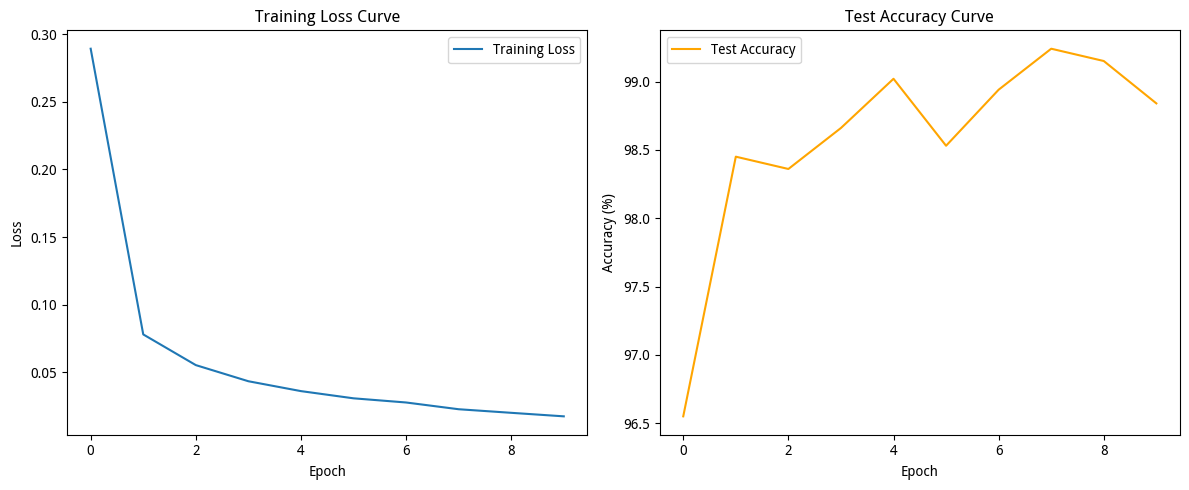

开始识别自定义手写数字...

文件名: 0.png, 预测数字: 0, 置信度: 99.99%
文件名: 1.png, 预测数字: 1, 置信度: 100.00%
文件名: 3.png, 预测数字: 3, 置信度: 100.00%
文件名: 4.png, 预测数字: 4, 置信度: 100.00%
文件名: 5.png, 预测数字: 5, 置信度: 100.00%


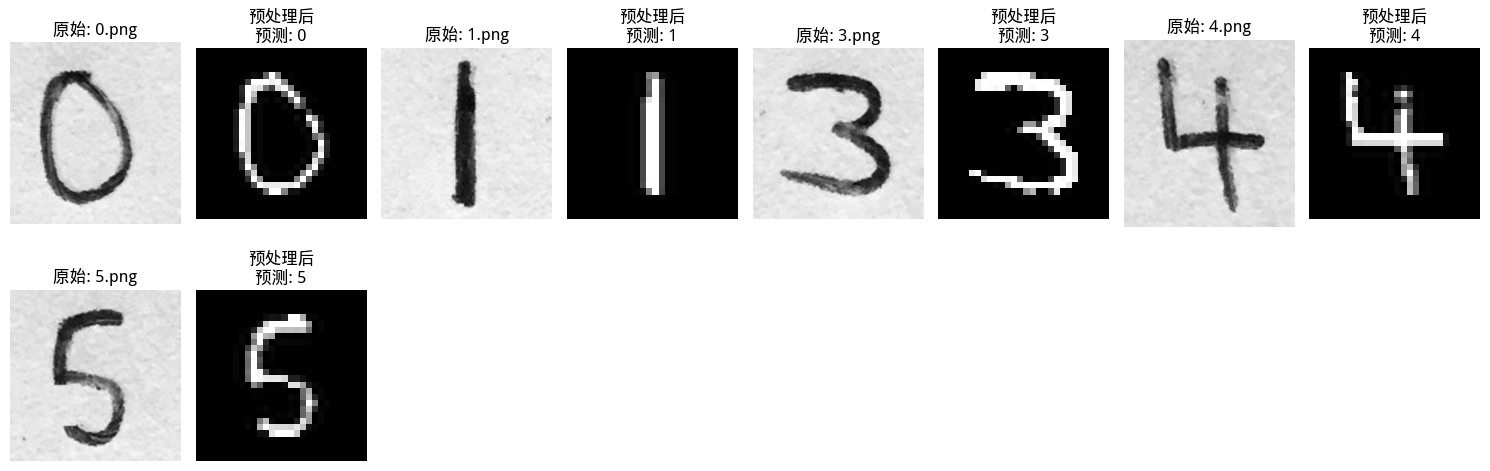

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import zipfile

# -------------------------- 1. 配置参数 --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
learning_rate = 0.001
num_epochs = 10
model_save_path = "lenet_mnist.pth"
digits_zip_path = "digits.zip"  
extract_path = "extracted_digits"

# -------------------------- 2. 定义LeNet-5模型 --------------------------
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # 卷积层1: 输入1通道(灰度), 输出6通道, 5x5卷积核
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)  # padding=2使28x28输入保持28x28
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)      # 输出14x14x6
        
        # 卷积层2: 输入6通道, 输出16通道, 5x5卷积核
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)            # 输出10x10x16
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)      # 输出5x5x16
        
        # 全连接层
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
        # 激活函数
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, 16 * 5 * 5)  # 展平
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# -------------------------- 3. 加载和预处理MNIST数据集 --------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST数据集的均值和标准差
])

# 下载并加载训练集和测试集
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# -------------------------- 4. 训练模型 --------------------------
def train_model():
    model = LeNet5().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    total_step = len(train_loader)
    train_losses = []
    test_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            
            # 前向传播
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # 反向传播和优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            if (i+1) % 100 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}")
        
        # 计算训练集平均损失
        avg_train_loss = running_loss / total_step
        train_losses.append(avg_train_loss)
        
        # 在测试集上评估
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        test_acc = 100 * correct / total
        test_accuracies.append(test_acc)
        print(f"Test Accuracy: {test_acc:.2f}%\n")
    
    # 保存模型
    torch.save(model.state_dict(), model_save_path)
    print(f"模型已保存至 {model_save_path}")
    
    # 绘制训练曲线
    plt.rcParams["font.sans-serif"] = [
    "SimHei",                # Windows 黑体
    "Microsoft YaHei",       # Windows 微软雅黑
    "PingFang SC",           # Mac 苹方
    "Hiragino Sans GB",      # Mac 冬青黑体
    "WenQuanYi Micro Hei",   # Linux 文泉驿微米黑
    "Heiti TC",              # 通用黑体
    "DejaVu Sans"  ]
    plt.rcParams["axes.unicode_minus"] = False
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(test_accuracies, label="Test Accuracy", color="orange")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Test Accuracy Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()
    
    return model

# -------------------------- 5. 自定义图像预处理函数（核心） --------------------------
def preprocess_custom_image(image_path):
    """
    将自定义手写数字图像转换为与MNIST风格一致的输入
    处理步骤：
    1. 转换为灰度图
    2. 调整大小为28x28
    3. 反转颜色（MNIST是黑底白字）
    4. 二值化处理
    5. 居中对齐
    6. 归一化
    """
    # 打开图像并转换为灰度图
    img = Image.open(image_path).convert("L")
    
    # 调整大小为28x28
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    
    # 转换为numpy数组
    img_np = np.array(img)
    
    # 反转颜色（如果是白底黑字）
    img_np = 255 - img_np
    
    # 二值化处理（去除噪声）
    threshold = 127
    img_np[img_np < threshold] = 0
    img_np[img_np >= threshold] = 255
    
    # 找到数字的边界框并居中
    coords = np.argwhere(img_np > 0)
    if coords.size == 0:
        # 如果没有找到数字，返回全黑图像
        return torch.zeros((1, 1, 28, 28)).to(device)
    
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    
    # 提取数字区域
    digit = img_np[y_min:y_max+1, x_min:x_max+1]
    
    # 计算需要添加的边距使数字居中
    h, w = digit.shape
    max_dim = max(h, w)
    pad_h = (max_dim - h) // 2
    pad_w = (max_dim - w) // 2
    
    # 添加边距
    padded = np.pad(digit, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant", constant_values=0)
    
    # 再次调整大小为20x20（保留一定边距）
    padded = Image.fromarray(padded).resize((20, 20), Image.Resampling.LANCZOS)
    padded = np.array(padded)
    
    # 添加4像素边距，最终得到28x28
    final_img = np.pad(padded, ((4, 4), (4, 4)), mode="constant", constant_values=0)
    
    # 转换为张量并归一化（与MNIST相同的均值和标准差）
    final_img = final_img.astype(np.float32) / 255.0
    final_img = (final_img - 0.1307) / 0.3081
    final_img = torch.from_numpy(final_img).unsqueeze(0).unsqueeze(0).to(device)
    
    return final_img

# -------------------------- 6. 识别自定义图像 --------------------------
def recognize_custom_digits(model):
    # 解压digits.zip
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)
    
    with zipfile.ZipFile(digits_zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    
    # 获取所有图像文件
    image_extensions = (".png", ".jpg", ".jpeg", ".bmp")
    image_files = [f for f in os.listdir(extract_path) if f.lower().endswith(image_extensions)]
    image_files.sort()  # 按文件名排序
    
    print("开始识别自定义手写数字...\n")
    results = []
    
    for image_file in image_files:
        image_path = os.path.join(extract_path, image_file)
        
        # 预处理图像
        processed_img = preprocess_custom_image(image_path)
        
        # 模型预测
        model.eval()
        with torch.no_grad():
            output = model(processed_img)
            _, predicted = torch.max(output.data, 1)
            probability = torch.nn.functional.softmax(output, dim=1)[0][predicted.item()].item()
        
        result = {
            "文件名": image_file,
            "预测数字": predicted.item(),
            "置信度": f"{probability*100:.2f}%"
        }
        results.append(result)
        print(f"文件名: {image_file}, 预测数字: {predicted.item()}, 置信度: {probability*100:.2f}%")
    
    # 可视化部分结果
    if len(results) > 0:
        plt.figure(figsize=(15, 10))
        for i, image_file in enumerate(image_files[:min(16, len(image_files))]):
            image_path = os.path.join(extract_path, image_file)
            original_img = Image.open(image_path).convert("L")
            processed_img = preprocess_custom_image(image_path).cpu().squeeze().numpy()
            
            plt.subplot(4, 8, 2*i+1)
            plt.imshow(original_img, cmap="gray")
            plt.title(f"原始: {image_file}")
            plt.axis("off")
            
            plt.subplot(4, 8, 2*i+2)
            plt.imshow(processed_img, cmap="gray")
            plt.title(f"预处理后\n预测: {results[i]['预测数字']}")
            plt.axis("off")
        
        plt.tight_layout()
        plt.savefig("recognition_results.png")
        plt.show()
    
    return results

# -------------------------- 7. 主函数 --------------------------
if __name__ == "__main__":
    # 训练模型（如果已有保存的模型，可以注释掉这行直接加载）
    model = train_model()
    
    # 加载已保存的模型
    # model = LeNet5().to(device)
    # model.load_state_dict(torch.load(model_save_path))
    
    # 识别自定义数字
    results = recognize_custom_digits(model)